In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

In [6]:
load_dotenv()

True

In [23]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.0,
    max_tokens = 1024
)

In [18]:
class LLMState(TypedDict):
    topic: str
    outline: str
    blog: str
    score: float

In [9]:
def llm_outline_generator(state: LLMState) -> LLMState:

    topic = state["topic"]

    prompt = f"For the given topic, provide a detailed outline for a blog of all necessary information related to the topic: {topic}"

    state["outline"] = llm.invoke(prompt).content

    return state

In [10]:
def llm_blog_generator(state: LLMState) -> LLMState:
    topic = state["topic"]
    outline = state["outline"]

    prompt = f"For the given topic and outline, create a blog. Topic = {topic}, Outline = {outline}"

    state["blog"] = llm.invoke(prompt).content

    return state


In [31]:
def llm_blog_evaluator(state: LLMState) -> LLMState:
    topic = state["topic"]
    outline = state["outline"]
    blog = state["blog"]

    prompt = f"""
    Evaluate the following blog based on correctness, biasness and relevance.

    Topic: {topic}
    Outline: {outline}
    Blog: {blog}

    Give a score between 1 and 10.
    Return ONLY the numerical score.
    Do not provide any explanation.
    """

    state["score"] = llm.invoke(prompt).content

    return state


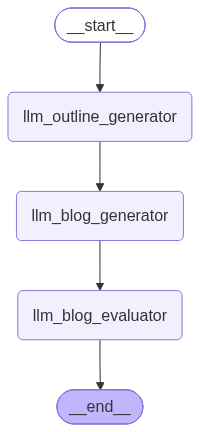

In [32]:
graph = StateGraph(LLMState)

graph.add_node("llm_outline_generator", llm_outline_generator)
graph.add_node("llm_blog_generator", llm_blog_generator)
graph.add_node("llm_blog_evaluator", llm_blog_evaluator)

graph.add_edge(START, "llm_outline_generator")
graph.add_edge("llm_outline_generator", "llm_blog_generator")
graph.add_edge("llm_blog_generator", "llm_blog_evaluator")
graph.add_edge("llm_blog_evaluator", END)

workflow = graph.compile()
workflow

In [33]:
initial_state = {
    "topic": "Rise of AI in India"
}

output_state = workflow.invoke(initial_state)

output_state

{'topic': 'Rise of AI in India',
 'outline': '**Blog Title:** *The Rise of AI in India – A Comprehensive Look at How the Sub‑Continent Is Shaping the Future of Artificial Intelligence*\n\n---\n\n## 1. Introduction  \n- **Hook:** A striking statistic (e.g., “India is projected to become the world’s largest AI market by 2030, worth $35\u202fbillion.”)  \n- **Why it matters:** AI’s impact on the economy, jobs, and global competitiveness.  \n- **Scope of the post:** From policy to startups, education, challenges, and the road ahead.\n\n---\n\n## 2. Historical Context  \n### 2.1 Early Foundations (1990‑2005)  \n- First AI research labs at IITs & IISc.  \n- Government’s “Technology Vision 2020” (1999) – early nod to AI.  \n\n### 2.2 The “Digital India” Era (2005‑2015)  \n- Launch of NIC’s AI initiatives.  \n- Emergence of BPOs leveraging early machine‑learning tools.  \n\n### 2.3 Acceleration Phase (2015‑Present)  \n- Global AI boom + Indian talent pool → rapid ecosystem growth.  \n\n---\n\n

In [29]:
print(output_state["outline"])

**Blog Title:** *The Rise of AI in India – A Comprehensive Look at How the Sub‑Continent Is Shaping the Future of Artificial Intelligence*

---

## 1. Introduction  
- **Hook:** A striking statistic (e.g., “India is projected to become the world’s largest AI market by 2030, worth $35 billion.”)  
- **Why it matters:** AI’s impact on the economy, jobs, and global competitiveness.  
- **Scope of the post:** From policy to startups, education, challenges, and the road ahead.

---

## 2. Historical Context  
### 2.1 Early Foundations (1990‑2005)  
- First AI research labs at IITs & IISc.  
- Government’s “Technology Vision 2020” (1999) – early nod to AI.  

### 2.2 The “Digital India” Era (2005‑2015)  
- Launch of NIC’s AI initiatives.  
- Emergence of BPOs leveraging early machine‑learning tools.  

### 2.3 Acceleration Phase (2015‑Present)  
- Global AI boom + Indian talent pool → rapid growth.  
- Key milestones (e.g., launch of AI research centers, first AI‑driven unicorns).

---

## 3

In [30]:
print(output_state["blog"])

# **The Rise of AI in India – A Comprehensive Look at How the Sub‑Continent Is Shaping the Future of Artificial Intelligence**

---

## 1. Introduction  

**Hook:** *India is projected to become the world’s largest AI market by 2030, worth **$35 billion** – a figure that dwarfs the combined AI spend of many developed economies today.*  

**Why it matters:**  
Artificial Intelligence is no longer a futuristic buzz‑word; it is a catalyst that is reshaping every pillar of the economy— from agriculture and healthcare to finance, manufacturing, and public services. For a country with a **population of 1.4 billion**, a thriving AI ecosystem can:

* **Super‑charge GDP growth** – AI‑driven productivity gains could add **$1 trillion** to India’s GDP by 2030.  
* **Create high‑skill jobs** – While automation will displace routine roles, AI will generate **millions of new positions** in data science, model engineering, AI ethics, and more.  
* **Boost global competitiveness** – A robust AI sector